# Cell 1: Chia tập dữ liệu cho bài toán Hồi quy

In [1]:
import pandas as pd
import numpy as np
from scipy import sparse
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('../')
from src.models.regression import RatingRegressor

df = pd.read_csv('../data/processed/cleaned_reviews.csv')
tfidf_matrix = sparse.load_npz('../data/processed/tfidf_matrix.npz')

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    tfidf_matrix, df['reviews.rating'], test_size=0.2, random_state=42
)

print(X_train_reg.shape)
print(y_train_reg.shape)

(26856, 3000)
(26856,)


/var/folders/s3/h6hv6qkd01d4qr6_nb2f3m3m0000gn/T/ipykernel_10909/885132588.py:12: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/processed/cleaned_reviews.csv')


# Cell 2: Huấn luyện, đánh giá và in kết quả MAE/RMSE

In [2]:
regressor = RatingRegressor(random_state=42)
regressor.train_all(X_train_reg, y_train_reg)
reg_results = regressor.evaluate_all(X_test_reg, y_test_reg)

metrics_df = pd.DataFrame({
    'Model': list(reg_results.keys()),
    'MAE': [res['MAE'] for res in reg_results.values()],
    'RMSE': [res['RMSE'] for res in reg_results.values()]
})

display(metrics_df)

,Model,MAE,RMSE
0,Baseline (Ridge),0.754087,1.047258
1,Strong Model (Random Forest),0.917649,1.200169


# Cell 3: Trực quan hóa sai số (Phục vụ viết báo cáo)

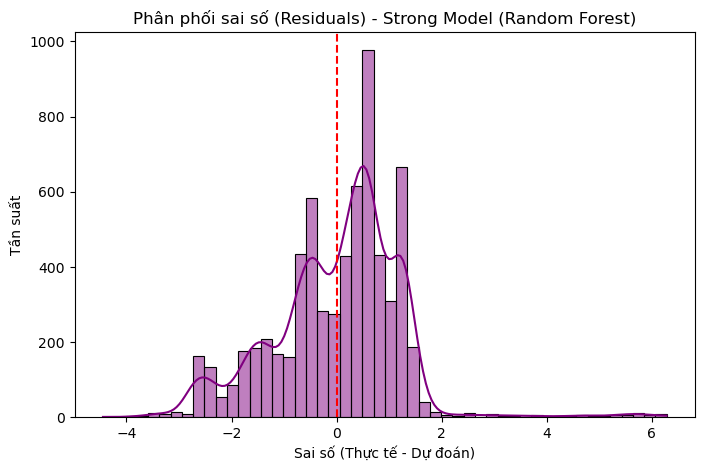

,Actual Rating,Predicted Rating,Absolute Error,Review
15135,5.0,2.981305,2.018695,"This is a very nice, comfortable hotel. And un..."
11892,5.0,2.457768,2.542232,Great red roof inn!!! Location is perfect. Qui...
9176,9.6,4.215564,5.384436,The renovations that have been done are very n...
24250,2.0,4.377665,2.377665,"OK, first the good...the front desk staff was ..."
11082,1.0,4.000642,3.000642,Poor check in.. Staff was unable to check us i...


In [3]:
best_reg_model = 'Strong Model (Random Forest)'
y_pred = reg_results[best_reg_model]['predictions']

plt.figure(figsize=(8, 5))
sns.histplot(y_test_reg - y_pred, bins=50, kde=True, color='purple')
plt.title(f'Phân phối sai số (Residuals) - {best_reg_model}')
plt.xlabel('Sai số (Thực tế - Dự đoán)')
plt.ylabel('Tần suất')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

error_df = pd.DataFrame({
    'Actual Rating': y_test_reg,
    'Predicted Rating': y_pred,
    'Absolute Error': np.abs(y_test_reg - y_pred),
    'Review': df.loc[y_test_reg.index, 'reviews.text']
})

high_error_cases = error_df[error_df['Absolute Error'] > 2.0]
display(high_error_cases.head())